In [1]:
from config import client
import pandas as pd

In [3]:
bills_query = """
SELECT * FROM zoho_books_analytics.bills
"""

result = client.query(bills_query)

bills_df = pd.DataFrame(result.result_rows, columns=[col for col in result.column_names])

In [10]:
bills_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67405 entries, 0 to 67404
Data columns (total 76 columns):
 #   Column                    Non-Null Count  Dtype                  
---  ------                    --------------  -----                  
 0   bill_id                   67405 non-null  object                 
 1   bill_number               67405 non-null  object                 
 2   bill_date                 67405 non-null  object                 
 3   due_date                  67405 non-null  object                 
 4   bill_status               67405 non-null  object                 
 5   sub_total_bcy             67405 non-null  object                 
 6   discount_                 67405 non-null  object                 
 7   total_bcy                 67405 non-null  object                 
 8   created_time              67405 non-null  datetime64[ns, Etc/UTC]
 9   last_modified_time        67405 non-null  datetime64[ns, Etc/UTC]
 10  vendor_id                 67405 no

In [5]:
bills_df.columns

Index(['bill_id', 'bill_number', 'bill_date', 'due_date', 'bill_status',
       'sub_total_bcy', 'discount_', 'total_bcy', 'created_time',
       'last_modified_time', 'vendor_id', 'discount', 'recurring_bill_id',
       'expected_payment_date', 'description', 'payment_terms',
       'payment_terms_label', 'purchase_order', 'currency_code',
       'exchange_rate', 'sub_total_fcy', 'total_fcy', 'balance_fcy',
       'address_id', 'balance_bcy', 'vendor_notes', 'terms__conditions', 'bl',
       'seal', 'vessel__voyage', 'container', 'custom_entry', 'shipment_terms',
       'fda_status', 'coo', 'customs_broker', 'eta', 'receipt_date',
       'inventory', 'withholding_tax_bcy', 'withholding_tax_fcy',
       'collection_letter', 'consignee', 'port_of_discharge', 'shipped_date',
       'discount_amount_bcy', 'discount_amount_fcy', 'adjustment',
       'adjustment_description', 'internal_notes', 'scac', 'place_of_delivery',
       'plant', 'ttr__lot', 'purchase_order_split__1', 'created_by',


In [12]:
len(bills_df)

67405

In [14]:
# Count duplicate bill_number entries
duplicate_count = bills_df['bill_number'].duplicated().sum()
print(f"Number of duplicate bill_number entries: {duplicate_count}")  


Number of duplicate bill_number entries: 523


## Bill Date

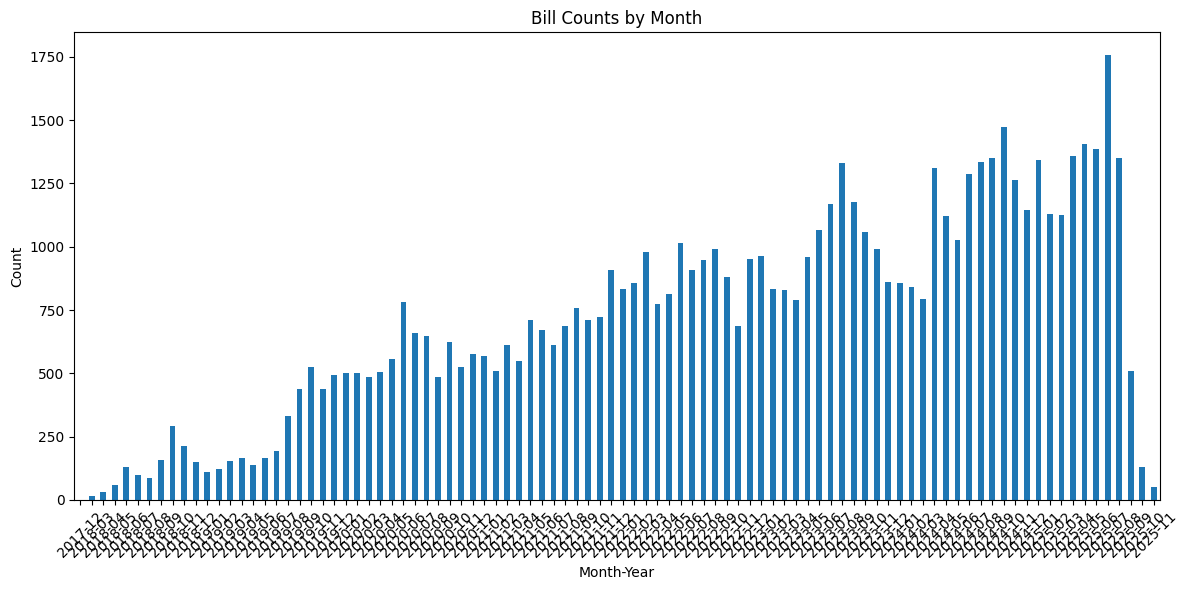

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

bills_df['bill_date'] = pd.to_datetime(bills_df['bill_date'])

monthly_counts = bills_df['bill_date'].dt.to_period('M').value_counts().sort_index()

plt.figure(figsize=(12, 6))
monthly_counts.plot(kind='bar')
plt.title('Bill Counts by Month')
plt.xlabel('Month-Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

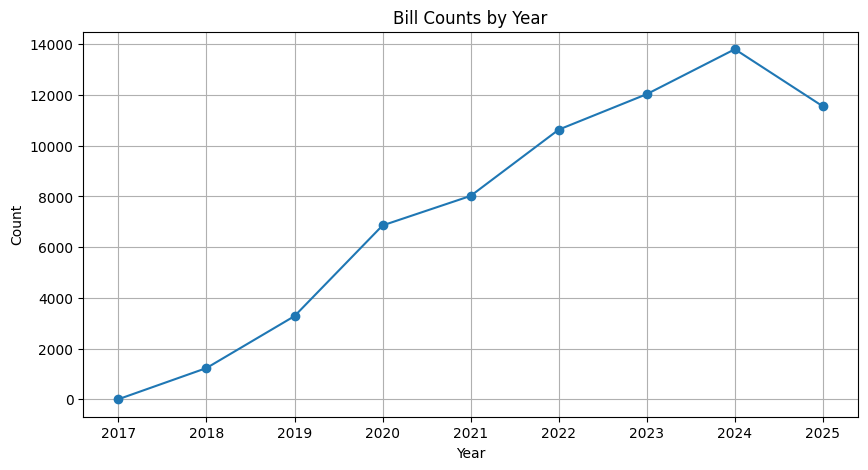

In [21]:
yearly_counts = bills_df['bill_date'].dt.year.value_counts().sort_index()
plt.figure(figsize=(10, 5))
yearly_counts.plot(kind='line', marker='o')
plt.title('Bill Counts by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.grid(True)
plt.show()

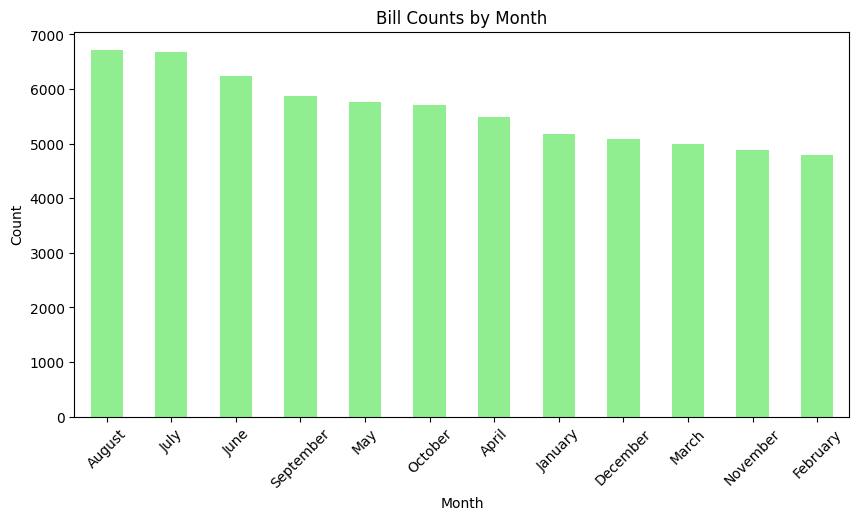

In [22]:
month_counts = bills_df['bill_date'].dt.month_name().value_counts()
plt.figure(figsize=(10, 5))
month_counts.plot(kind='bar', color='lightgreen')
plt.title('Bill Counts by Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [76]:
counts = bills_df['bill_date'].value_counts()
outliers = counts[counts > counts.mean() + 3 * counts.std()]
print("Outlier dates with high bill counts:\n", outliers)

Outlier dates with high bill counts:
 bill_date
2024-04-01    260
2022-12-01    228
2025-07-01    194
2024-10-16    144
2022-09-01    143
2022-07-01    140
2023-08-01    131
2023-11-01    128
2022-03-01    127
2024-10-01    124
2023-07-01    115
2021-11-01    114
2024-11-01    114
2022-06-01    114
2025-05-01    110
2022-11-01    109
2025-07-16    108
2025-08-01    108
2023-05-01    107
2025-04-01    106
2024-07-31    105
2021-03-01    103
2025-01-15    102
2025-07-09    102
2024-09-30    102
2025-04-16    101
2022-02-01    100
2024-12-02     99
2025-03-31     98
2025-06-30     97
2023-09-01     97
2025-05-28     96
2023-12-01     96
2023-06-30     96
2024-11-07     95
2025-04-30     95
2025-06-11     95
2025-07-21     95
2025-06-04     95
2024-04-30     94
Name: count, dtype: int64


In [24]:
high_count_dates = bills_df['bill_date'].value_counts().head()
for date in high_count_dates.index:
    print(f"Duplicate bill_numbers on {date}:")
    print(bills_df[bills_df['bill_date'] == date]['bill_number'].duplicated().sum())

Duplicate bill_numbers on 2024-04-01 00:00:00:
1
Duplicate bill_numbers on 2022-12-01 00:00:00:
3
Duplicate bill_numbers on 2025-07-01 00:00:00:
3
Duplicate bill_numbers on 2024-10-16 00:00:00:
0
Duplicate bill_numbers on 2022-09-01 00:00:00:
3


## Due Date

In [28]:
bills_df['due_date'] = pd.to_datetime(bills_df['due_date'])

Payment term stats (days):
count    67405.000000
mean        17.479727
std         28.047491
min          0.000000
25%          0.000000
50%          0.000000
75%         30.000000
max        420.000000
Name: payment_term, dtype: float64


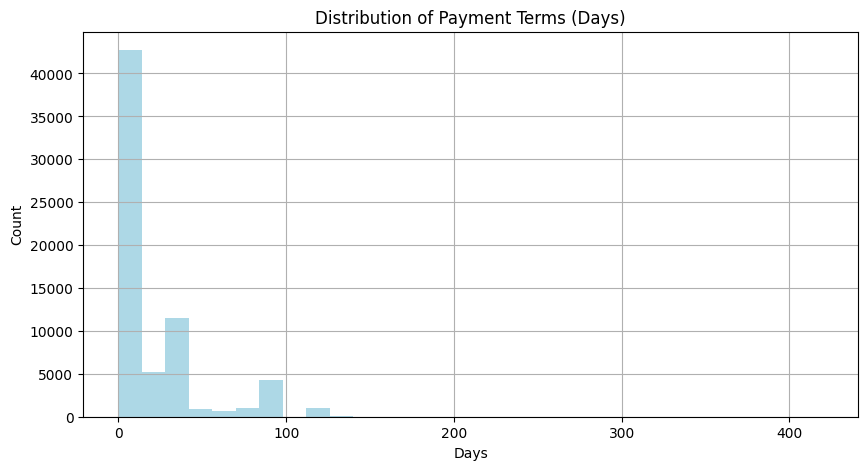

In [30]:
# Calculate time difference
bills_df['payment_term'] = (bills_df['due_date'] - bills_df['bill_date']).dt.days

# Summary statistics
print("Payment term stats (days):")
print(bills_df['payment_term'].describe())

# Plot histogram of payment terms
plt.figure(figsize=(10, 5))
bills_df['payment_term'].hist(bins=30, color='lightblue')
plt.title('Distribution of Payment Terms (Days)')
plt.xlabel('Days')
plt.ylabel('Count')
plt.show()

In [32]:
current_date = pd.Timestamp('2025-09-23')
overdue_bills = bills_df[bills_df['due_date'] < current_date]
print(f"Number of overdue bills: {len(overdue_bills)}")

Number of overdue bills: 66651


## Bill Status 

In [33]:
bills_df['bill_status'].value_counts()

bill_status
Paid              66512
Draft               375
Open                319
Void                111
Overdue              86
Partially Paid        2
Name: count, dtype: int64

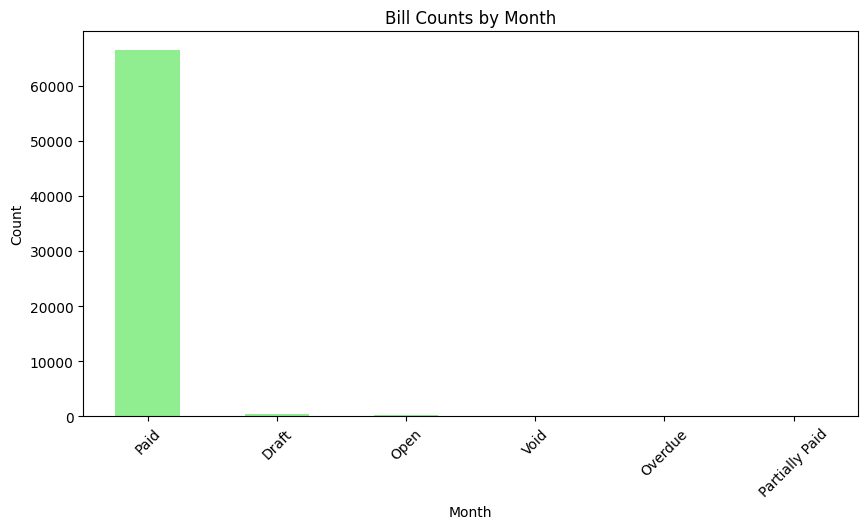

In [36]:
bill_counts = bills_df['bill_status'].value_counts()
plt.figure(figsize=(10, 5))
bill_counts.plot(kind='bar', color='lightgreen')
plt.title('Bill Counts by Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

## Sub Total Bcy

In [39]:
# bills_df['sub_total_bcy'].head(n=5)
bills_df['sub_total_bcy'] = bills_df['sub_total_bcy'].str.replace('USD ', '', regex=False).str.replace(',', '').astype(float)

In [40]:
print("Descriptive Statistics for sub_total_bcy:")
print(bills_df['sub_total_bcy'].describe())

Descriptive Statistics for sub_total_bcy:
count     67405.000000
mean      43890.023979
std       65239.378232
min           0.000000
25%         884.000000
50%        2682.500000
75%      107835.000000
max      854784.000000
Name: sub_total_bcy, dtype: float64


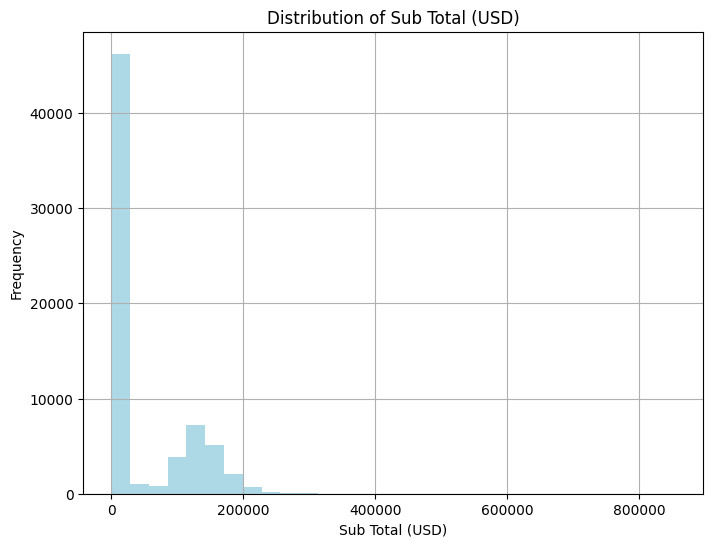

In [47]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
bills_df['sub_total_bcy'].hist(bins=30, color='lightblue')
plt.title('Distribution of Sub Total (USD)')
plt.xlabel('Sub Total (USD)')
plt.ylabel('Frequency')
plt.show()

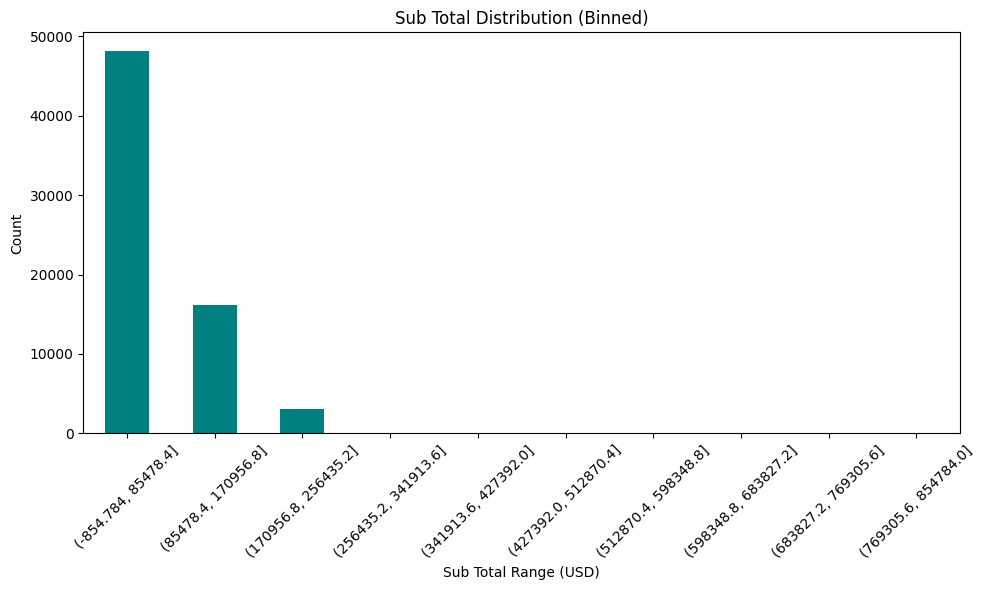

In [58]:
import matplotlib.pyplot as plt

# Bin sub_total_bcy for better visualization
bins = pd.cut(bills_df['sub_total_bcy'], bins=10)
bin_counts = bins.value_counts().sort_index()

# Plot bar graph
plt.figure(figsize=(10, 6))
bin_counts.plot(kind='bar', color='teal')
plt.title('Sub Total Distribution (Binned)')
plt.xlabel('Sub Total Range (USD)')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [59]:
print("Missing sub_total_bcy values:", bills_df['sub_total_bcy'].isna().sum())
print("Negative or zero amounts:", len(bills_df[bills_df['sub_total_bcy'] <= 0]))

Missing sub_total_bcy values: 0
Negative or zero amounts: 14


# Discount

In [61]:
# bills_df['discount'].head(n=5)
bills_df['discount'] = bills_df['discount'].astype(float)

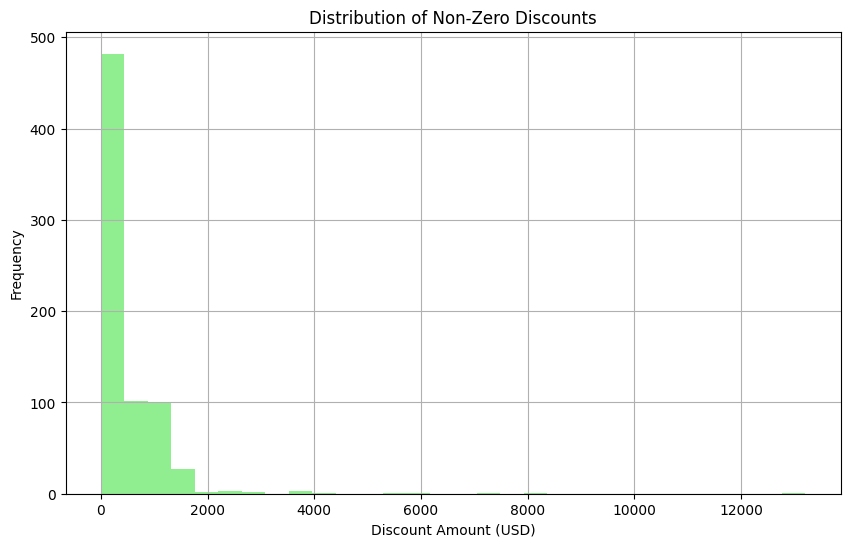

In [62]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
bills_df[bills_df['discount'] > 0]['discount'].hist(bins=30, color='lightgreen')
plt.title('Distribution of Non-Zero Discounts')
plt.xlabel('Discount Amount (USD)')
plt.ylabel('Frequency')
plt.show()

In [64]:
zero_discounts = bills_df[bills_df['discount'] == 0]
print("Average sub_total_bcy for zero discounts:", zero_discounts['sub_total_bcy'].mean())

Average sub_total_bcy for zero discounts: 43916.08464890968


In [66]:
Q1 = bills_df['discount'].quantile(0.25)
Q3 = bills_df['discount'].quantile(0.75)
IQR = Q3 - Q1
outliers = bills_df[(bills_df['discount'] > Q3 + 1.5 * IQR) & (bills_df['discount'] > 0)]
print(f"Number of discount outliers: {len(outliers)}")

Number of discount outliers: 727


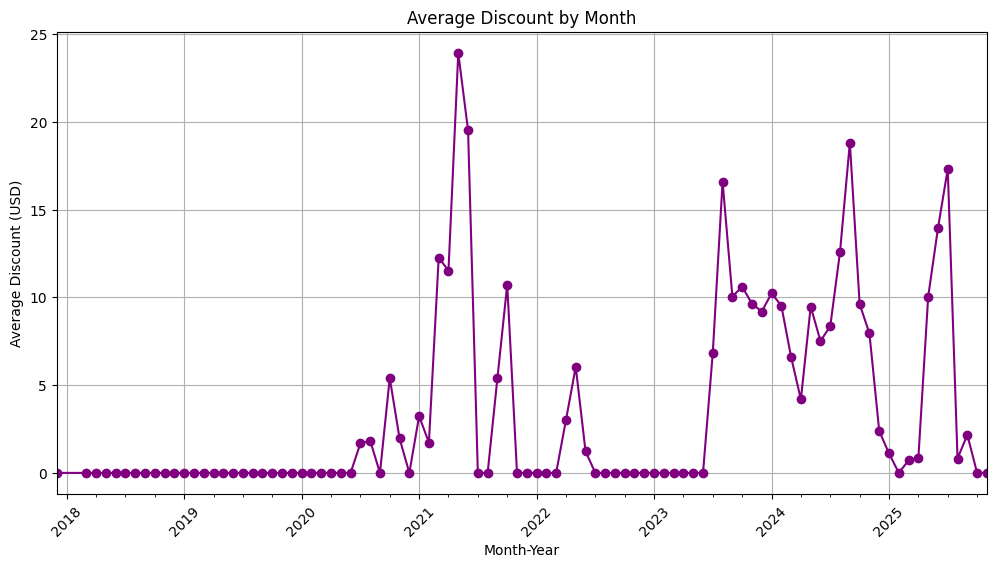

In [68]:
monthly_discounts = bills_df.groupby(bills_df['bill_date'].dt.to_period('M'))['discount'].mean()
plt.figure(figsize=(12, 6))
monthly_discounts.plot(kind='line', marker='o', color='purple')
plt.title('Average Discount by Month')
plt.xlabel('Month-Year')
plt.ylabel('Average Discount (USD)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

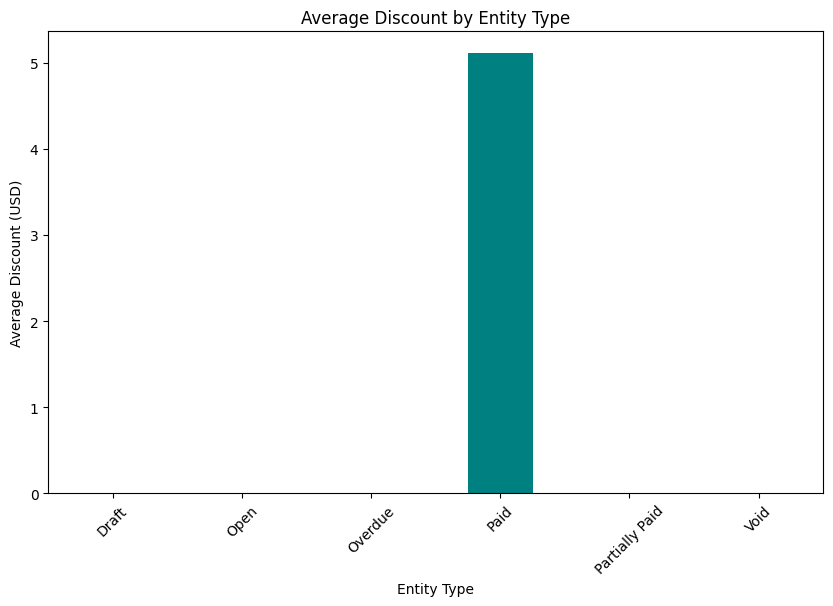

In [69]:
entity_discounts = bills_df.groupby('bill_status')['discount'].mean()
plt.figure(figsize=(10, 6))
entity_discounts.plot(kind='bar', color='teal')
plt.title('Average Discount by Entity Type')
plt.xlabel('Entity Type')
plt.ylabel('Average Discount (USD)')
plt.xticks(rotation=45)
plt.show()

In [70]:
duplicates = bills_df[bills_df['bill_number'].duplicated(keep=False)]
print("Discounts for duplicate bill_numbers:")
print(duplicates.groupby('bill_number')['discount'].agg(['count', 'mean', 'std']))

Discounts for duplicate bill_numbers:
                count  mean  std
bill_number                     
                  122   0.0  0.0
#2                  2   0.0  0.0
#3                  2   0.0  0.0
'-                  7   0.0  0.0
'--                 2   0.0  0.0
...               ...   ...  ...
9741                2   0.0  0.0
976402              2   0.0  0.0
977207              2   0.0  0.0
AZ4664/0059622      2   0.0  0.0
reimbursement       2   0.0  0.0

[367 rows x 3 columns]


## Sub_total_bcy == Total_bcy
## discount_ is percentage and discount is actual amount